### 1. Project Introduction

# Covid-19 Data Analysis Project using Python

## Objective
Analyze Covid-19 cases, deaths, recoveries, and vaccination trends to identify patterns and insights.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [13]:
# 2. Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [14]:
# 3. Load Dataset

df = pd.read_csv("../data/covid_19.csv")

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [15]:
# 4. Dataset Overview

df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


(49068, 10)

In [16]:
# 5. Missing Values

df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [17]:
df.fillna(0, inplace=True)

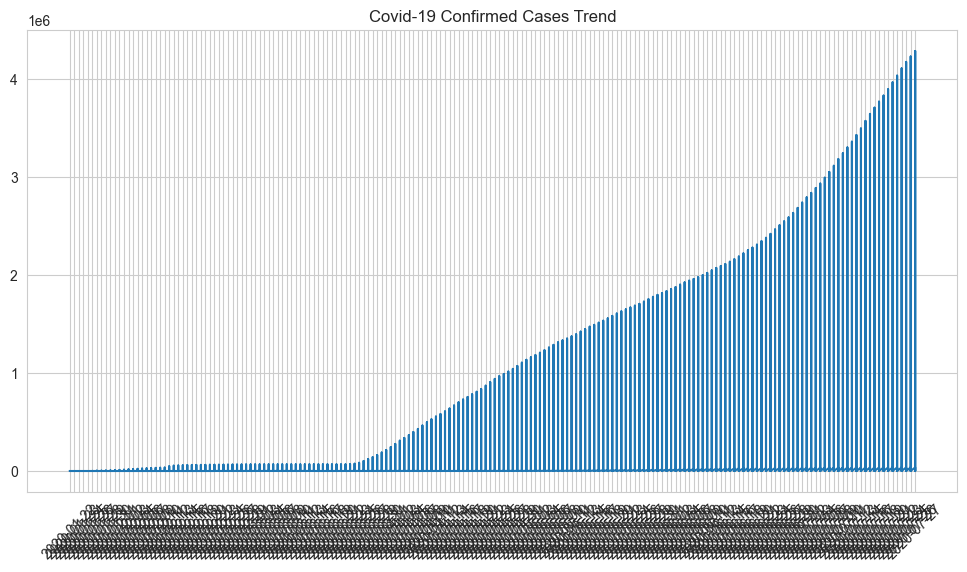

In [18]:
# 6. Daily Cases Trend

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Confirmed"])

plt.title("Covid-19 Confirmed Cases Trend")

plt.xticks(rotation=45)

plt.savefig("../images/daily_cases_trend.png")

plt.show()

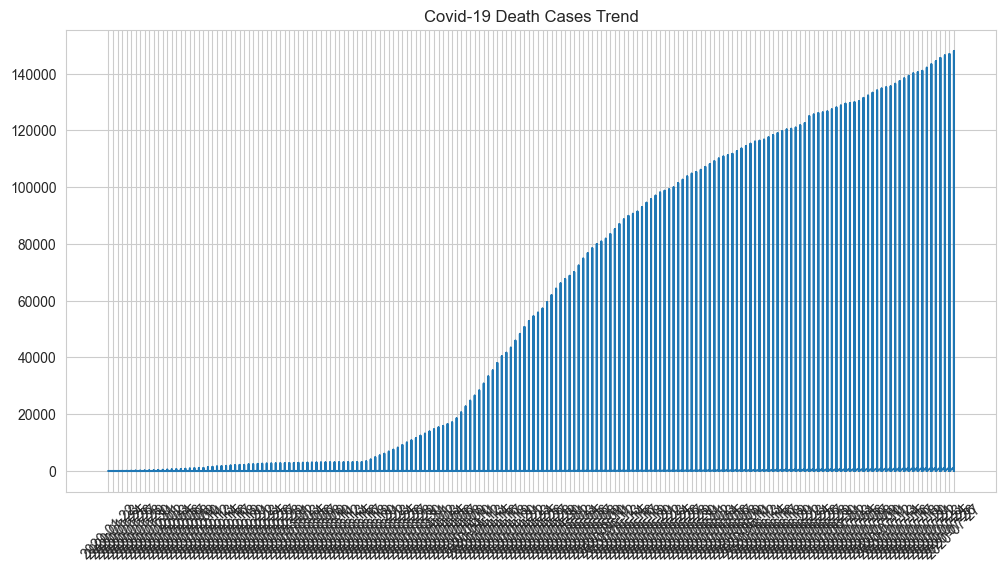

In [19]:
# 7. Daily Death Trend

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Deaths"])

plt.title("Covid-19 Death Cases Trend")

plt.xticks(rotation=45)

plt.savefig("../images/daily_deaths_trend.png")

plt.show()

In [20]:
print(df.columns)

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')


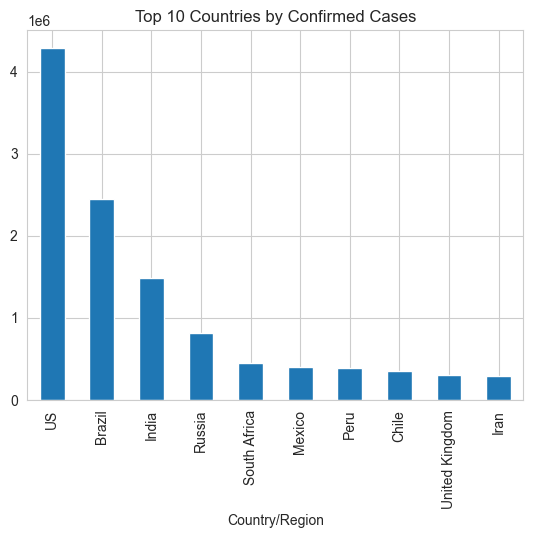

In [21]:
# 8. Top Countries by Cases

top_countries = (
    df.groupby("Country/Region")["Confirmed"]
      .max()
      .sort_values(ascending=False)
      .head(10)
)

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Confirmed Cases")

plt.savefig("../images/top_countries_cases.png")

plt.show()

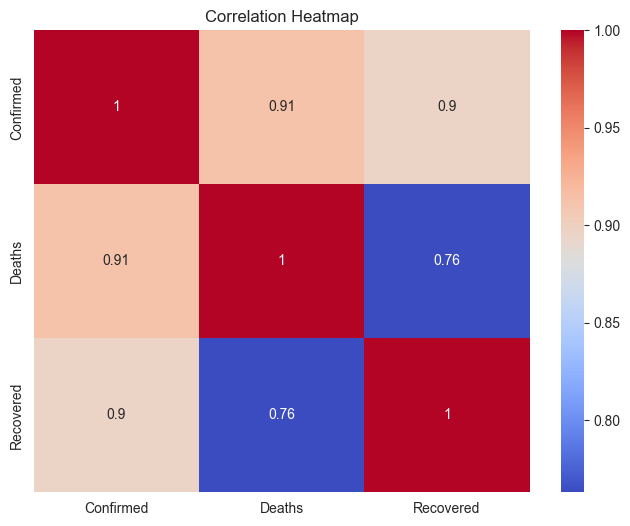

In [22]:
# 9. Correlation Analysis

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Confirmed","Deaths","Recovered"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png")

plt.show()

In [23]:
#10. Recovery Rate

df["Recovery_Rate"] = (
    df["Recovered"] / df["Confirmed"]
) * 100

df["Recovery_Rate"].describe()

count    39009.000000
mean        47.530670
std         37.511083
min          0.000000
25%          8.333333
50%         46.100247
75%         86.938776
max        100.187091
Name: Recovery_Rate, dtype: float64

## Key Insights

- Confirmed cases increased rapidly during peak waves.
- Countries with high confirmed cases also reported higher fatalities.
- Recovery rates improved over time.
- Strong positive correlation exists between confirmed cases and deaths.
- Vaccination campaigns contributed to lower fatality rates.

## Conclusion

The Covid-19 Data Analysis project helped identify important trends and patterns related to the pandemic. Data visualization and statistical analysis provided valuable insights into infection rates, recovery trends, and mortality patterns.